In [94]:
#### Importando modulos
import pandas as pd
import numpy as np
import scipy
from scipy import stats
import matplotlib.pyplot as plt


In [95]:
##### Funcion para integrar posiciones
def posiciones(df_r: pd.DataFrame, empresas: list[str], tipo:str):
    df_posiciones = pd.DataFrame()
    #### Extracciones individuales
    if tipo=='sliding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'SlidingFinalPreds/pred_sliding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='expanding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'ExpandingFinalPreds/pred_expanding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='todo':
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [1] * df_r.shape[0]
    elif tipo=='rand':
        import random
        random.seed(42)
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [random.randint(0,1) for _ in range(df_r.shape[0])]


    #### Asegurando que df_posiciones tenga mismo numero de datos
    df_posiciones = df_posiciones.iloc[:df_r.shape[0]]

    #### Camiando indices
    df_posiciones.index = df_r.index
    
    #### Sumando cantidad de posiciones
    suma = df_posiciones.sum(axis=1)

    #### Asignando posiciones equitativamente
    df_posiciones_finales = df_posiciones.div(suma, axis=0)

    #### Integrando posiciones con rendimientos
    df_integrado = pd.concat([df_r,df_posiciones_finales], axis=1, ignore_index=False)

    return df_integrado


In [96]:
##### Calculando formula para la rentabilidad del portafolio

def calc_rentabilidad(df:pd.Dataframe, empresas: list[str], tgt: int = 0.1, costo : int = 0.00001) -> pd.Dataframe:
    """
    Formula para calcular la rentabilidad de un portafolio 

    Params:
    df: el dataframe que contiene los rendimientos, EWMSD, y posiciones del portafolio
    tgt: la voltatilidad deseada para escalar la volatilidad proporcionalmente
    costo: costo de cambiar las posiciones de las acciones en un portafolio
  l
    Return:
    df_rentabilidad: el df que contiene la rentabilidad del portafolio por las fechas marcadas
    """
    #### Calculando rentabilidad equitativa por cada accion/empresa
    df_rentabilidad = pd.DataFrame()
    for name in empresas:
        df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * (tgt/df[f'EWMSD.{name}'].shift(1))  * df[f'Posicion.{name}'].shift(1) - \
        costo*abs(((tgt/df[f'EWMSD.{name}'].shift(1))*df[f'Posicion.{name}'].shift(1)) - ((tgt/df[f'EWMSD.{name}'].shift(2))*df[f'Posicion.{name}'].shift(2)))
        # df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * df[f'Posicion.{name}']


    #### Elimando primera dos fila por el "shift(2)"
    df_rentabilidad_diaria = df_rentabilidad.iloc[2:]

    return df_rentabilidad_diaria



In [97]:
#### Formula para cargar y limpiar datos
def cargar(nom:str):
    ### Cargando datos
    df = pd.read_csv(nom, index_col='Date')

    ### Nombre de las 32 empresas
    empresas = df.columns.to_list()

    ### Calculando EWMSD
    for name in empresas:
        df[f'EWMSD.{name}'] = df[name].ewm(span=30, adjust=False).std()

    ### Eliminando datos
    df = df.iloc[:-62]
    df = df.iloc[345:]

    #### Calculando posiciones
    df_posiciones= posiciones(df, empresas, 'todo')    

    #### Calculado rentabilidades diarias de todas acciones
    df_rentabilidad_diaria = calc_rentabilidad(df_posiciones, empresas)
    
    return df_rentabilidad_diaria
    

In [98]:
#### Funcion para hacer test 1 y test 2 (retest)
def test(df:pd.DataFrame, fecha_comienzo: str, dias: int, offset: int):
    ### Extrayendo df
    df_deseado = df.loc[fecha_comienzo:]

    ### Selecionado fechas iniciales
        # Va a ver un dia de separacion para integrar la preddicion del LSTM
    df_inicial = df_deseado.iloc[offset:dias+offset]    #Valores Inicial
    df_final = df_deseado.iloc[offset+1:dias+offset+1]    #Valores Finales
    

    print(f'Fechas iniciales: {df_inicial.iloc[0].name}, {df_inicial.iloc[-1].name}\t Fechas finales: {df_final.iloc[0].name}, {df_final.iloc[-1].name}')

    ### Rendimientos
    ## Valores esperados
    df_inicial_rend_esperados = df_inicial.mean(axis=0)
    df_final_rend_esperados = df_final.mean(axis=0)

    ## Indice rendimiento
    df_indice_rend = (df_final_rend_esperados - df_inicial_rend_esperados)/(df_inicial_rend_esperados + 1e-8)


    ### Desviacion estandard 
    ## Valores
    df_inicial_std = df_inicial.std(axis=0, ddof=0)
    df_final_std = df_final.std(axis=0, ddof=0)

    ## Indice
    df_indice_std = (df_final_std - df_inicial_std)/(df_inicial_std + 1e-8)

    # return df_indice_rend.to_list(), df_indice_std.to_list()                        # Instrumento original
    return df_inicial_rend_esperados.to_list(), df_inicial_std.to_list()            # Instrumento modificado

In [99]:
#### Funcion para ejecutar las pruebas
def pruebas(df: pd.DataFrame, test1_fecha: str, dias: int, diff: int):
    '''
    df: dataframe
    test1_fecha: fecha de comienzo
    dias: dias dentro del periodo de std y expected returns
    diff: diferencia entre test 1 y test 2 (retest)
    '''

    ### Creando indices
    indice_rend_test1, indice_std_test1 = test(df, test1_fecha, dias, 0)
    indice_rend_test2, indice_std_test2 = test(df, test1_fecha, dias, diff)


    ### Probando normalidad: 32 > 30 => usar Kolgomorov smirnov
    norm_rend_test1_estad, norm_rend_test1_pvalor = stats.kstest(indice_rend_test1, 'norm')
    norm_rend_test2_estad, norm_rend_test2_pvalor = stats.kstest(indice_rend_test2, 'norm')
    norm_std_test1_estad, norm_std_test1_pvalor = stats.kstest(indice_std_test1, 'norm')
    norm_std_test2_estad, norm_std_test2_pvalor = stats.kstest(indice_std_test2, 'norm')

    ### Correlacion Spearman
    ALT = 'two-sided'      #'two-sided', 'less', 'greater'; solo cambia pvalor
    spear_rend_estad, spear_rend_pvalor = stats.spearmanr(indice_rend_test1, indice_rend_test2, alternative=ALT)
    spear_std_estad, spear_std_pvalor = stats.spearmanr(indice_std_test1, indice_std_test2, alternative=ALT)

    ### Correlacion Pearson
    pear_rend_estad, pear_rend_pvalor = stats.pearsonr(indice_rend_test1, indice_rend_test2)
    pear_std_estad, pear_std_pvalor = stats.pearsonr(indice_std_test1, indice_std_test2)

    ### Tabla visual
    ## Creado tabla
    data = np.array([
        [norm_rend_test1_estad, norm_rend_test1_pvalor],
        [norm_rend_test2_estad, norm_rend_test2_pvalor],
        [norm_std_test1_estad, norm_std_test1_pvalor],
        [norm_std_test2_estad, norm_std_test2_pvalor],
        [spear_rend_estad, spear_rend_pvalor],
        [spear_std_estad, spear_std_pvalor],
        [pear_rend_estad, pear_rend_pvalor],
        [pear_std_estad, pear_std_pvalor]
    ])

    ## Nombres de columnas y filas
    cols = ['Resultado', 'P-valor (>0.05?)']
    rows = ['Norm Rend Test 1','Norm Rend Test 2', 'Norm Vol Test 1','Norm Vol Test 2',
            'Spearman Rend', 'Spearman Vol', 'Pearson Rend', 'Pearson Vol']
    
    ## Creando colores
    NORM_THRESH = 0.05
    colores = [['white','white']] * 8
    if (norm_rend_test1_pvalor > NORM_THRESH) and (norm_rend_test2_pvalor > NORM_THRESH):
        # Indice rendimiento son normales
        colores[6] = ['yellow', 'white']
    else: 
        colores[4] = ['yellow', 'white']

    
    if (norm_std_test1_pvalor > NORM_THRESH) and (norm_std_test2_pvalor > NORM_THRESH):
        # Inice vol son normales; ejemplo: 2009-02-03', 2009-03-03'
        colores[7] = ['yellow', 'white']
    else: 
        colores[5] = ['yellow', 'white']

    ## Configurando tabla
    ANCHURA = 7
    ALTURA = 3
    fig, ax = plt.subplots(figsize=(ANCHURA,ALTURA))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,           # Datos en formato lista o array
        colLabels=cols, # Encabezados de columnas
        rowLabels=rows,    # Encabezados de filas
        cellColours=colores,    # Colores
        loc='center',            # Posición de la tabla
        cellLoc='center'         # Alineación del texto en las celdas
    )

    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    # tabla.scale(ANCHURA*0.25, ALTURA*0.25)

    plt.show()

In [100]:
#### Cargando datos
rentabilidad_diaria_origin = cargar('retornos.csv')


Fechas iniciales: 2018-04-05, 2018-05-16	 Fechas finales: 2018-04-06, 2018-05-17
Fechas iniciales: 2018-04-25, 2018-06-05	 Fechas finales: 2018-04-26, 2018-06-06
Fechas iniciales: 2018-04-05, 2018-05-16	 Fechas finales: 2018-04-06, 2018-05-17
Fechas iniciales: 2018-04-25, 2018-06-05	 Fechas finales: 2018-04-26, 2018-06-06


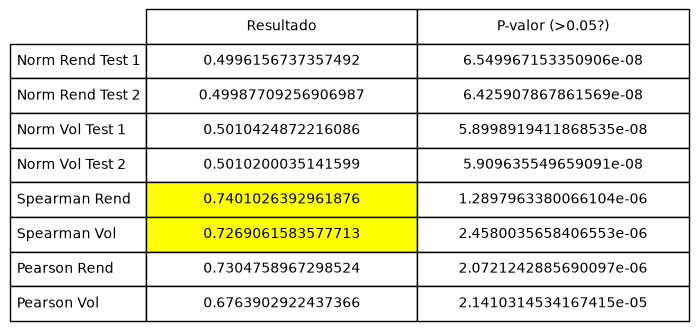

In [101]:
#### Ejecutando pruebas
fecha_test1 = '2018-04-05'
dias = 30
diff = 14
indice_rend_test1, indice_std_test1 = test(rentabilidad_diaria_origin, fecha_test1, dias, 0)
indice_rend_test2, indice_std_test2 = test(rentabilidad_diaria_origin, fecha_test1, dias, diff)


#### Retornos originales
pruebas(rentabilidad_diaria_origin, fecha_test1, dias=30, diff=14)

In [ ]:
#### Funcion para extraer estadisticas
def estadisticas(df:pd.DataFrame):
    ### Creando arreglo de estadisticas
    arr = []
    arr.append(df.mean())    # Promedio
    arr.append(df.median())  # Mediana
    arr.append(df.std(ddof=0))   # Des Est
    arr.append(df.min())     # Minimo
    arr.append(df.max())     # Maximo

    ### Buscando el exponente comun
    arr = np.array(arr, dtype=float)
    exponentes = np.floor(np.log10(np.abs(arr)))
    exp_comun = int(scipy.stats.mode(exponentes)[0])

    ### Ajustando valores
    resultados = arr/(10**exp_comun)
    resultados = np.round(resultados, 2)
    resultados = [int(df.shape[0])] + resultados.tolist()

    return (resultados, exp_comun)

In [132]:
##### Extrayendo informacion
def normalidad(data1: list, data2:list, nom:str):
    ### Creando histograma
    HIST_ANCH = 12
    HIST_ALT = 5
    fig, axs = plt.subplots(1,2, figsize=(HIST_ANCH, HIST_ALT), sharex=False, sharey=False)
    
    ### Histograma 1
    ## Histograma mismo
    min_val = min(data1)
    max_val = max(data1)
    num_centros = int(1 + (np.log(len(data1))/ np.log(2)))
    centros = np.linspace(min_val, max_val, num_centros)
    cuentas, bordes, parches = axs[0].hist(data1, bins=centros, edgecolor='black')

    ## Configuranciones 
    axs[0].set_title(f'Normalidad {nom}: Test')
    axs[0].set_xlabel('Rango de Valores')
    axs[0].set_ylabel('Frecuencia de Valores en Rango')

    ## Arreglando eje x
    bordes_rangos = [f"{int(bordes[i])}–{int(bordes[i+1])}" for i in range(len(bordes)-1)]
    axs[0].set_xticks((bordes[:-1] + bordes[1:])/2)
    axs[0].set_xticklabels(bordes_rangos)

    
    ### Histograma 2
    ## Histograma mismo
    min_val = min(data2)
    max_val = max(data2)
    num_centros = int(1 + (np.log(len(data2))/ np.log(2)))
    centros = np.linspace(min_val, max_val, num_centros)
    cuentas, bordes, parches = axs[1].hist(data2, bins=centros, edgecolor='black')

    ## Configuranciones 
    axs[1].set_title(f'Normalidad {nom}: Retest')
    axs[1].set_xlabel('Rango de Valores')
    axs[1].set_ylabel('Cantidad de Valores en Rango')



Fechas iniciales: 2018-04-05, 2018-05-16	 Fechas finales: 2018-04-06, 2018-05-17
Fechas iniciales: 2018-04-25, 2018-06-05	 Fechas finales: 2018-04-26, 2018-06-06


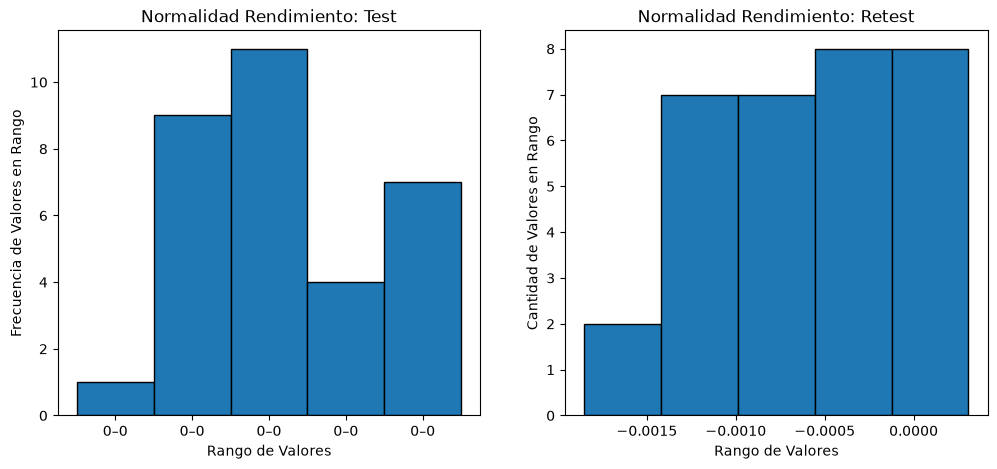

In [133]:
#### Ejecutando pruebas
fecha_test1 = '2018-04-05'
dias = 30
diff = 14
indice_rend_test1, indice_std_test1 = test(rentabilidad_diaria_origin, fecha_test1, dias, 0)
indice_rend_test2, indice_std_test2 = test(rentabilidad_diaria_origin, fecha_test1, dias, diff)


normalidad(indice_rend_test1, indice_rend_test2, 'Rendimiento')